# Modelo Machine Learning

In [1]:
%cd ..

c:\Users\juanw\Desktop\garbage-classification


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.carga import cargar_datos
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
import os

## Carga de Datos

In [4]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
1585,data/Garbage-classification/Garbage-classifica...,paper
964,data/Garbage-classification/Garbage-classifica...,metal
1111,data/Garbage-classification/Garbage-classifica...,metal
1582,data/Garbage-classification/Garbage-classifica...,paper
2139,data/Garbage-classification/Garbage-classifica...,plastic


## Carga de Datos desde Colab

In [ ]:
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification", path="data/")

print(f"📦 Dataset descargado en: {path}")

## Division de los Datos 

In [5]:
from sklearn.model_selection import train_test_split

# 80% train, 20% (test + validación)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['y']
 )

# Del 20% (test + validacion): 10% validación y 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['y']
 )

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validación: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 2021 (80.0%)
Validación: 253 (10.0%)
Test: 253 (10.0%)


## Modificacion de las imagenes y carga en memoria.

In [6]:
def load_images(df, size):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        ruta = row['x']
        label = row['y']
        
        img = cv2.imread(ruta)                  
        img = cv2.resize(img, (size, size))    
        img = img.astype('float32') / 255.0    
        
        images.append(img)
        labels.append(label)
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y

In [7]:
x_train, y_train = load_images(train_df, size=128)
x_val, y_val = load_images(val_df, size=128)
x_test, y_test = load_images(test_df, size=128)

In [8]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2021, 128, 128, 3),
 (2021,),
 (253, 128, 128, 3),
 (253,),
 (253, 128, 128, 3),
 (253,))

In [9]:
X_train = x_train.reshape(x_train.shape[0], -1)
X_val   = x_val.reshape(x_val.shape[0], -1)
X_test  = x_test.reshape(x_test.shape[0], -1)

Encoding para los labels

In [10]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)
y_test  = le.transform(y_test)

In [11]:
le.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype='<U9')

## Aplicamos modelo de clasificacion

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [13]:
model = RandomForestClassifier(random_state=42, n_jobs=1)

In [14]:
#Buscamos mejores parametros 
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [15]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [16]:
# Usar el mejor modelo encontrado
model = grid_search.best_estimator_

In [17]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

In [18]:

acc_train_rf = accuracy_score(y_train, y_train_pred)
acc_val_rf = accuracy_score(y_val, y_val_pred)
acc_test_rf = accuracy_score(y_test, y_test_pred)

print(f"Random Forest - Accuracy Train: {acc_train_rf:.4f}")
print(f"Random Forest - Accuracy Val: {acc_val_rf:.4f}")
print(f"Random Forest - Accuracy Test: {acc_test_rf:.4f}")

Random Forest - Accuracy Train: 0.9980
Random Forest - Accuracy Val: 0.6324
Random Forest - Accuracy Test: 0.6640


In [19]:
print("Classification Report - Train:")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

Classification Report - Train:
              precision    recall  f1-score   support

   cardboard       1.00      0.99      1.00       322
       glass       1.00      1.00      1.00       401
       metal       1.00      1.00      1.00       328
       paper       1.00      1.00      1.00       475
     plastic       0.99      1.00      0.99       385
       trash       1.00      1.00      1.00       110

    accuracy                           1.00      2021
   macro avg       1.00      1.00      1.00      2021
weighted avg       1.00      1.00      1.00      2021



In [20]:
print("Classification Report - Validation:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Classification Report - Validation:
              precision    recall  f1-score   support

   cardboard       0.72      0.82      0.77        40
       glass       0.50      0.56      0.53        50
       metal       0.53      0.41      0.47        41
       paper       0.72      0.83      0.78        60
     plastic       0.61      0.58      0.60        48
       trash       1.00      0.29      0.44        14

    accuracy                           0.63       253
   macro avg       0.68      0.58      0.60       253
weighted avg       0.64      0.63      0.62       253



In [21]:
print("Classification Report - Test:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Classification Report - Test:
              precision    recall  f1-score   support

   cardboard       0.68      0.73      0.71        41
       glass       0.55      0.58      0.56        50
       metal       0.60      0.44      0.51        41
       paper       0.71      0.86      0.78        59
     plastic       0.74      0.71      0.73        49
       trash       0.71      0.38      0.50        13

    accuracy                           0.66       253
   macro avg       0.67      0.62      0.63       253
weighted avg       0.66      0.66      0.66       253



In [22]:
n_params_rf = sum(tree.tree_.node_count for tree in model.estimators_)
print(f"\nNúmero de parámetros (nodos) del Random Forest: {n_params_rf}")


Número de parámetros (nodos) del Random Forest: 65056


In [23]:
def plot_confusion(y_true, y_pred, class_names, title='Matriz de confusion'):
    # Redondear predicciones a etiquetas enteras
    y_pred_labels = np.rint(y_pred).astype(int)
    y_pred_labels = np.clip(y_pred_labels, 0, len(class_names) - 1)

    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred_labels, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.show()

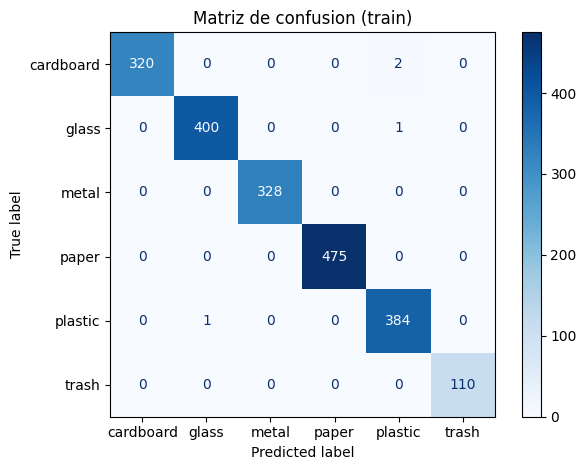

In [24]:
plot_confusion(y_train, y_train_pred, le.classes_, title='Matriz de confusion (train)')

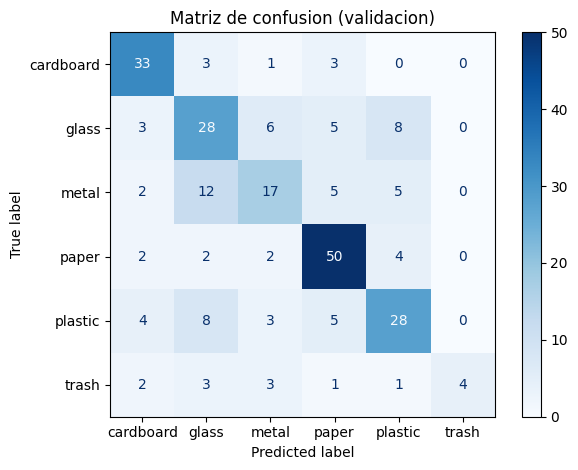

In [25]:
plot_confusion(y_val, y_val_pred, le.classes_, title='Matriz de confusion (validacion)')

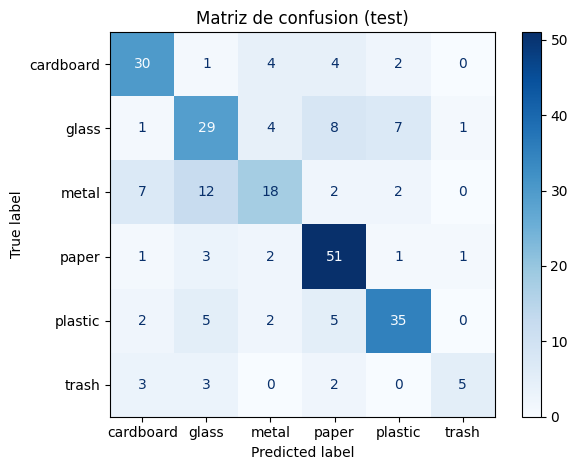

In [26]:
plot_confusion(y_test, y_test_pred, le.classes_, title='Matriz de confusion (test)')